# Demo: Comparing SirojFlow to PyTorch

Note: This is not model training, it is just a comparision between two framework. Since SirojFlow is an educational framework, PyTorch is taken for reference, not replication, goal is to see how simalarly model trains in SirojFlow to that of PyTorch to insure mathematical reliability.

In [ ]:
!pip install sirojflow

In [ ]:
from SirojFlow.engine.nn import Sequential, Linear
from SirojFlow.engine.act import ReLU, Sigmoid, Softmax
from SirojFlow.losses import BinaryCrossentropyLoss, SparseCategoricalCrossentropyLoss, MSELoss
from SirojFlow.optims import ADAM
from SirojFlow.utils import DataLoader

import numpy as np
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

## For Classification

### Multiclass Clasisfication

In [218]:
x, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_classes=5, random_state=42)

In [219]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

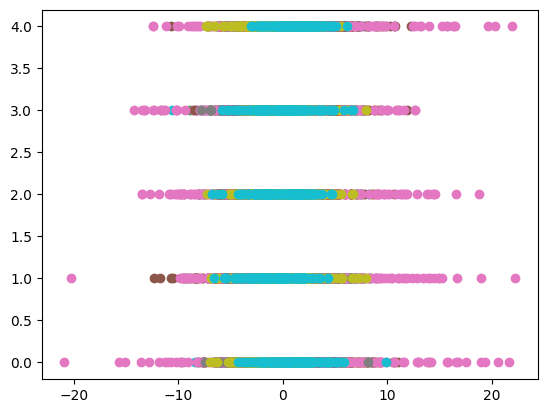

In [220]:
plt.plot(x_train, y_train, "o")
plt.show()

In [221]:
train_loader = DataLoader(x_train, y_train, batch_size=32, shuffle=True, drop_last=True)

In [222]:
train_loader.__iter__().__next__()[0].shape

(32, 20)

In [223]:
model_ns1 = Sequential(
    Linear(20, 64, init_type="he"),
    ReLU(),
    Linear(64, 32),
    Linear(32, 5),
    Softmax()
)

In [ ]:
criterion_ns1 = SparseCategoricalCrossentropyLoss(model_ns1.layers[-1])
optimizer_ns1 = Adam(model_ns1, lr = 0.001)

In [225]:
loses_ns1 = []
for epoch in range(100):
    epoch_loss = 0

    for x_batch, y_batch in train_loader:
        pred = model_ns1(x_batch)
        loss = criterion_ns1(pred, y_batch)

        criterion_ns1.backward()
        optimizer_ns1.step()

        epoch_loss += loss

    loses_ns1.append(epoch_loss)

    if epoch%10 == 0:
      print(f"Epoch {epoch}: {epoch_loss:.4f}")

Epoch 0: 38.6331
Epoch 10: 17.4317
Epoch 20: 11.6451
Epoch 30: 7.6772
Epoch 40: 5.1343
Epoch 50: 3.0942
Epoch 60: 1.8737
Epoch 70: 1.0720
Epoch 80: 0.6437
Epoch 90: 0.4099


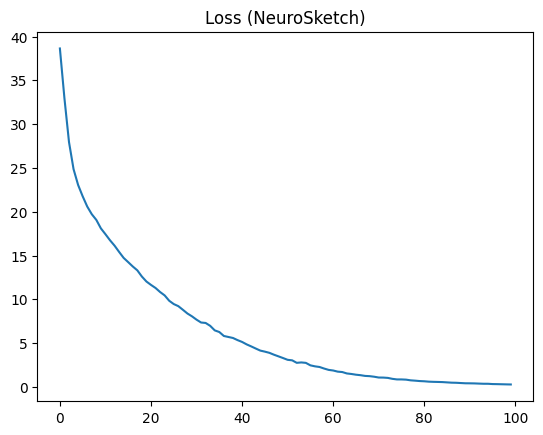

In [ ]:
plt.title("Loss (SirojFlow)")
plt.plot(loses_ns1)
plt.show()

With pytorch with same architecture

In [227]:
model_t1 = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.Linear(32, 5),
)

In [228]:
criterion_t1 = nn.CrossEntropyLoss()
optimizer_t1 = optim.Adam(model_t1.parameters(), lr=0.001)

In [229]:
loses_t1 = []
for epoch in range(100):
    epoch_loss = 0

    for xb, yb in train_loader:
        xb = torch.tensor(xb, dtype=torch.float32)
        yb = torch.tensor(yb, dtype=torch.long)

        optimizer_t1.zero_grad()
        pred = model_t1(xb)
        l = criterion_t1(pred, yb.squeeze())

        l.backward()
        optimizer_t1.step()

        epoch_loss += l.item()

    loses_t1.append(epoch_loss)

    if epoch%10 == 0:
      print(f"Epoch {epoch+1}: {epoch_loss:.4f}")

Epoch 1: 37.9598
Epoch 11: 14.7500
Epoch 21: 8.4389
Epoch 31: 4.8752
Epoch 41: 2.6431
Epoch 51: 1.4533
Epoch 61: 0.7710
Epoch 71: 0.4648
Epoch 81: 0.3028
Epoch 91: 0.2045


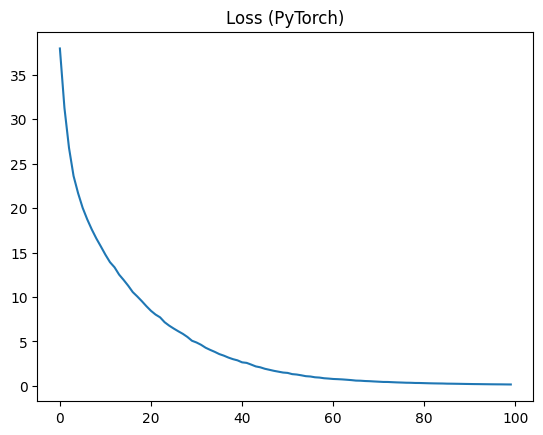

In [230]:
plt.title("Loss (PyTorch)")
plt.plot(loses_t1)
plt.show()

We can see, loss converges in similar way, the slight difference is caused by weight initializations, seed for random weight generation, and shuffling of data. Now, comparing accuracy.

In [ ]:
# NeuroSketch

prediction_test_ns1 = model_ns1(x_test)
prediction_test_ns1_argmax = np.argmax(prediction_test_ns1, axis=1)

accuracy = np.mean(prediction_test_ns1_argmax == y_test)
print(f"Accuracy: {accuracy*100:.2f}%")

loss_test_t1= criterion_ns1(prediction_test_ns1, y_test)
print(f"Loss: {loss_test_t1:.4f}")

Accuracy: 76.50%
Loss: 1.0305


In [ ]:
# PyTorch
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

prediction_test_t1 = model_t1(x_test_t)
prediction_test_t1_argmax = torch.argmax(prediction_test_t1, dim=1)

accuracy = torch.mean((prediction_test_t1_argmax == y_test_t).float())
print(f"Accuracy: {accuracy*100:.2f}%")

loss_test_t1 = criterion_t1(prediction_test_t1, y_test_t)
print(f"Loss: {loss_test_t1:.4f}")

Accuracy: 74.00%
Loss: 1.2794


We can see the accuracy is much similar in both the frameworks, this implies that the code is mathematically sound

### Binary Classification

In [ ]:
x, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_classes=2, random_state=42)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

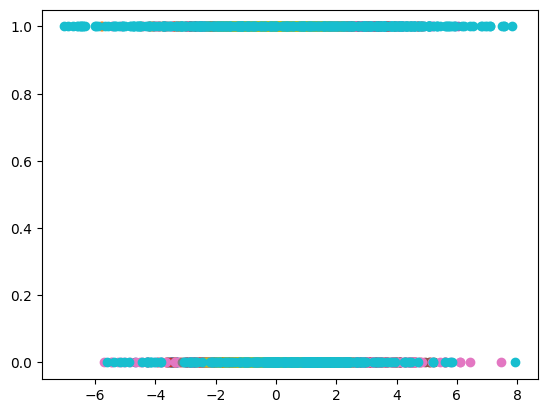

In [ ]:
plt.plot(x_train, y_train, "o")
plt.show()

In [ ]:
train_loader = DataLoader(x_train, y_train, batch_size=32, shuffle=True, drop_last=True)

In [ ]:
model_ns1 = Sequential(
    Linear(10, 64, init_type="he"),
    ReLU(),
    Linear(64, 32),
    ReLU(),
    Linear(32, 1),
    Sigmoid()
)

In [ ]:
criterion_ns1 = BinaryCrossentropyLoss(model_ns1.layers[-1])
optimizer_ns1 = Adam(model_ns1, lr = 0.001)

In [ ]:
loses_ns1 = []
for epoch in range(100):
    epoch_loss = 0

    for x_batch, y_batch in train_loader:
        pred = model_ns1(x_batch)
        loss = criterion_ns1(pred, y_batch)

        criterion_ns1.backward()
        optimizer_ns1.step()

        epoch_loss += loss

    loses_ns1.append(epoch_loss)

    if epoch%10 == 0:
      print(f"Epoch {epoch}: {epoch_loss:.4f}")

Epoch 0: 17.0351
Epoch 10: 6.0242
Epoch 20: 4.5261
Epoch 30: 3.6516
Epoch 40: 3.0580
Epoch 50: 2.5694
Epoch 60: 2.1474
Epoch 70: 1.8837
Epoch 80: 1.5809
Epoch 90: 1.3731


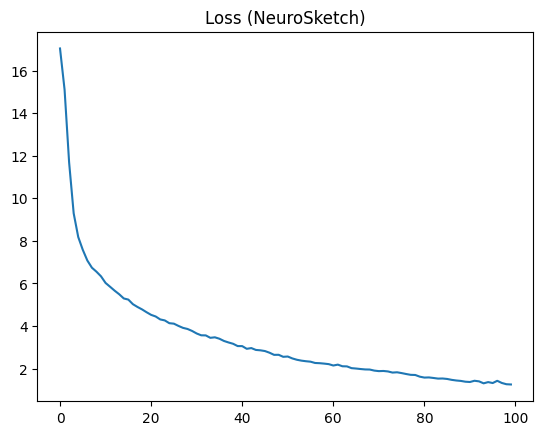

In [ ]:
plt.title("Loss (SirojFlow)")
plt.plot(loses_ns1)
plt.show()

In [ ]:
model_t1 = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

In [ ]:
criterion_t1 = nn.BCELoss()
optimizer_t1 = optim.Adam(model_t1.parameters(), lr=0.001)

In [ ]:
loses_t1 = []
for epoch in range(100):
    epoch_loss = 0

    for xb, yb in train_loader:
        xb = torch.tensor(xb, dtype=torch.float32)
        yb = torch.tensor(yb, dtype=torch.float32)

        optimizer_t1.zero_grad()
        pred = model_t1(xb)
        l = criterion_t1(pred, yb)

        l.backward()
        optimizer_t1.step()

        epoch_loss += l.item()

    loses_t1.append(epoch_loss)

    if epoch%10 == 0:
      print(f"Epoch {epoch+1}: {epoch_loss:.4f}")

Epoch 1: 15.8304
Epoch 11: 5.6243
Epoch 21: 3.6273
Epoch 31: 2.7514
Epoch 41: 2.1753
Epoch 51: 1.8700
Epoch 61: 1.6598
Epoch 71: 1.2941
Epoch 81: 1.0045
Epoch 91: 0.7196


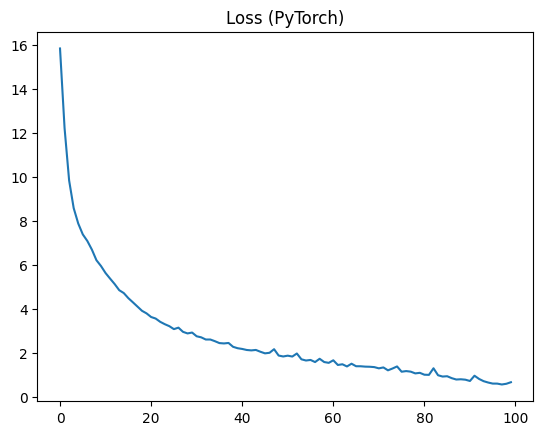

In [ ]:
plt.title("Loss (PyTorch)")
plt.plot(loses_t1)
plt.show()

We can see, loss converges in similar way, the slight difference is caused by weight initializations, seed for random weight generation, and shuffling of data. Now, comparing accuracy.

In [ ]:
# NeuroSketch

prediction_test_ns1 = model_ns1(x_test)
prediction_test_ns1_argmax = np.argmax(prediction_test_ns1, axis=1)

accuracy = np.mean(prediction_test_ns1_argmax == y_test)
print(f"Accuracy: {accuracy*100:.2f}%")

loss_test_t1= criterion_ns1(prediction_test_ns1.squeeze(), y_test)
print(f"Loss: {loss_test_t1:.4f}")

Accuracy: 49.50%
Loss: 0.2772


In [ ]:
# PyTorch
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

prediction_test_t1 = model_t1(x_test_t)
prediction_test_t1_argmax = torch.argmax(prediction_test_t1, dim=1)

accuracy = torch.mean((prediction_test_t1_argmax == y_test_t).float())
print(f"Accuracy: {accuracy*100:.2f}%")

loss_test_t1 = criterion_t1(prediction_test_t1.squeeze(), y_test_t)
print(f"Loss: {loss_test_t1:.4f}")

Accuracy: 49.50%
Loss: 0.2484


It is seen results for binary classification are also similar

## For Regression / MLP

In [ ]:
x, y = make_regression(n_samples=1000, n_features=7, n_informative=4, noise=0.001)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
train_loader = DataLoader(x_train, y_train, batch_size=32, shuffle=True, drop_last=True)

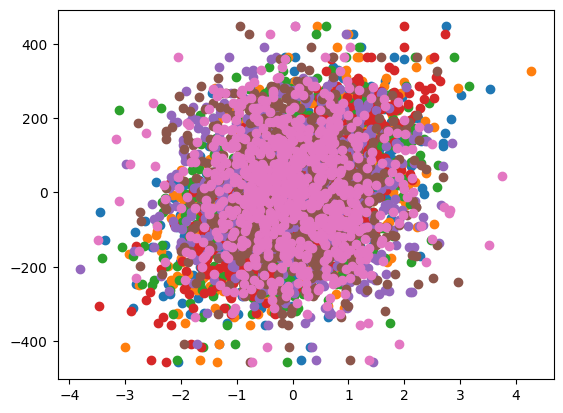

In [ ]:
plt.plot(x_train, y_train, 'o')
plt.show()

In [ ]:
model_ns1 = Sequential(
    Linear(7, 64, init_type="he"),
    Linear(64, 32),
    ReLU(),
    Linear(32, 16),
    Linear(16, 1),
)

In [ ]:
criterion_ns1 = MSELoss(model_ns1.layers[-1])
optimizer_ns1 = ADAM(model_ns1, lr = 0.001)

In [ ]:
loses_ns1 = []
for epoch in range(100):
    epoch_loss = 0

    for x_batch, y_batch in train_loader:
        pred = model_ns1(x_batch)
        loss = criterion_ns1(pred, y_batch)

        criterion_ns1.backward()
        optimizer_ns1.step()

        epoch_loss += loss

    loses_ns1.append(epoch_loss)

    if epoch%10 == 0:
      print(f"Epoch {epoch}: {epoch_loss:.4f}")

Epoch 0: 543736.8012
Epoch 10: 105.0933
Epoch 20: 56.1282
Epoch 30: 43.9661
Epoch 40: 32.4867
Epoch 50: 22.9544
Epoch 60: 14.9206
Epoch 70: 8.8827
Epoch 80: 4.9363
Epoch 90: 2.4287


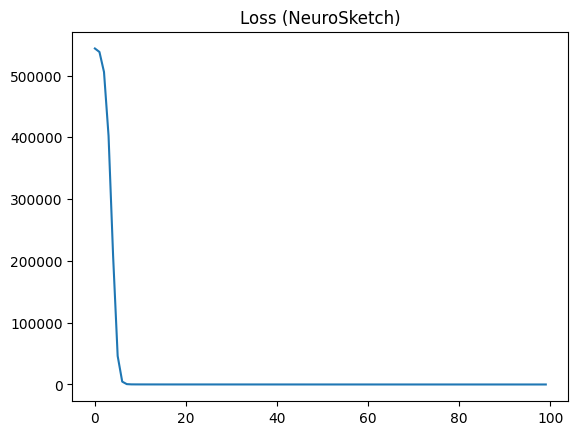

In [ ]:
plt.title("Loss (SirojFlow)")
plt.plot(loses_ns1)
plt.show()

Line of best fit

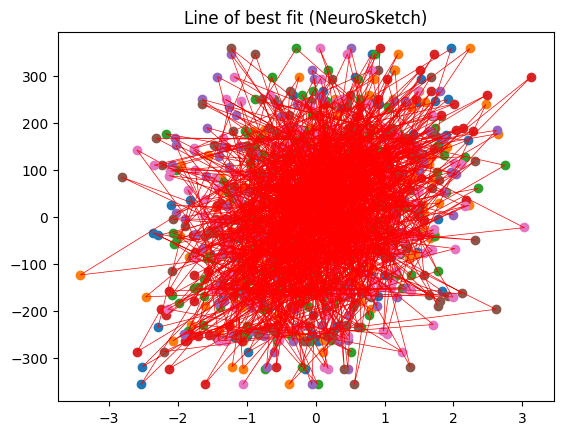

In [ ]:
prediction_test_ns1 = model_ns1(x_test)
plt.title("Line of best fit (NeuroSketch)")
plt.plot(x_test, y_test, 'o', label='Data Points')
plt.plot(x_test, prediction_test_ns1, color='red', linewidth=0.5, label=f'model')
plt.show()

It is quite messy, but this red line is the model trained in NeuroSketch.

In [ ]:
model_t1 = nn.Sequential(
    nn.Linear(7, 64),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.Linear(16, 1)
)

In [ ]:
criterion_t1 = nn.MSELoss()
optimizer_t1 = optim.Adam(model_t1.parameters(), lr=0.001)

In [ ]:
loses_t1 = []
for epoch in range(100):
    epoch_loss = 0

    for xb, yb in train_loader:
        xb = torch.tensor(xb, dtype=torch.float32)
        yb = torch.tensor(yb, dtype=torch.float32)

        optimizer_t1.zero_grad()
        pred = model_t1(xb)
        l = criterion_t1(pred, yb)

        l.backward()
        optimizer_t1.step()

        epoch_loss += l.item()

    loses_t1.append(epoch_loss)

    if epoch%10 == 0:
      print(f"Epoch {epoch+1}: {epoch_loss:.4f}")

Epoch 1: 543045.4971
Epoch 11: 4653.6107
Epoch 21: 472.8925
Epoch 31: 16.4901
Epoch 41: 5.2911
Epoch 51: 3.8927
Epoch 61: 2.8176
Epoch 71: 2.0181
Epoch 81: 1.4711
Epoch 91: 1.1066


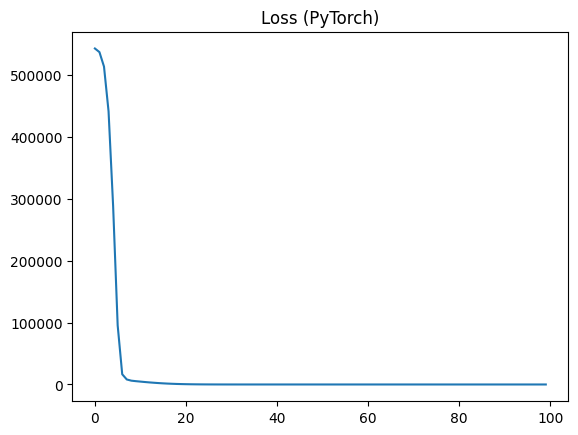

In [ ]:
plt.title("Loss (PyTorch)")
plt.plot(loses_t1)
plt.show()

Line of best fit

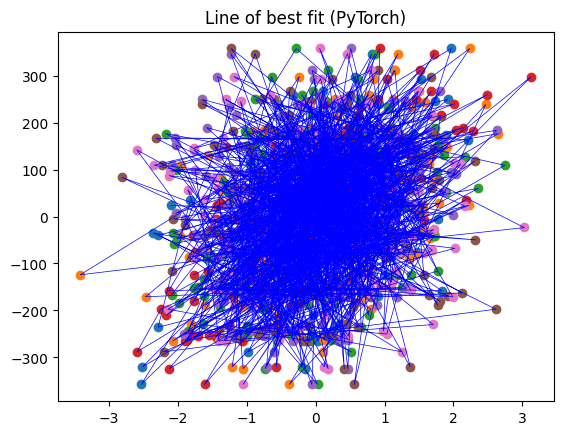

In [ ]:
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
prediction_test_t1 = model_t1(x_test_t)
prediction_t1 = prediction_test_t1.detach().numpy()

plt.title("Line of best fit (PyTorch)")
plt.plot(x_test, y_test, 'o', label='Data Points')
plt.plot(x_test, prediction_t1, color='blue', linewidth=0.5, label=f'model')
plt.show()

The blue like is the model trained in PyTorch